In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pets-facial-expression-dataset/Other/aug-88-54.jpg
/kaggle/input/pets-facial-expression-dataset/Other/45.jpg
/kaggle/input/pets-facial-expression-dataset/Other/56.jpg
/kaggle/input/pets-facial-expression-dataset/Other/aug-141-02.jpg
/kaggle/input/pets-facial-expression-dataset/Other/20.jpg
/kaggle/input/pets-facial-expression-dataset/Other/aug-37-49.jpg
/kaggle/input/pets-facial-expression-dataset/Other/58.jpg
/kaggle/input/pets-facial-expression-dataset/Other/aug-168-37.jpg
/kaggle/input/pets-facial-expression-dataset/Other/aug-80-43.jpg
/kaggle/input/pets-facial-expression-dataset/Other/aug-183-55.jpg
/kaggle/input/pets-facial-expression-dataset/Other/aug-114-30.jpg
/kaggle/input/pets-facial-expression-dataset/Other/aug-152-19.jpg
/kaggle/input/pets-facial-expression-dataset/Other/aug-180-52.jpg
/kaggle/input/pets-facial-expression-dataset/Other/aug-195-12.jpg
/kaggle/input/pets-facial-expression-dataset/Other/aug-123-39.jpg
/kaggle/input/pets-facial-expression-dataset/

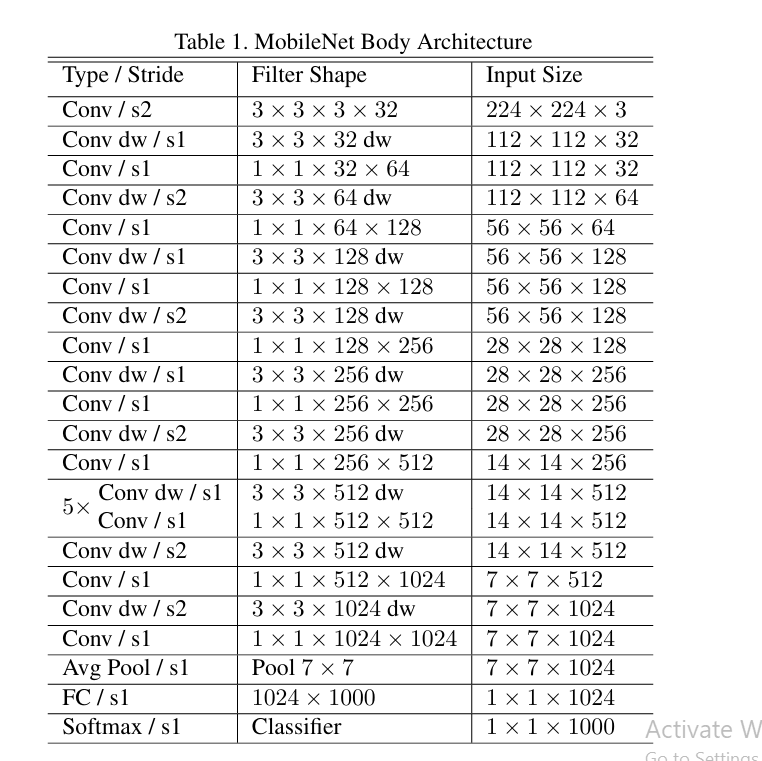

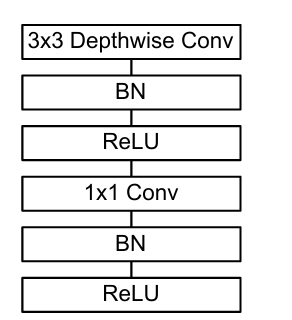

In [2]:
import tensorflow as tf
def Mob_block(X,pw_filters,stride=1):
    
    X = tf.keras.layers.DepthwiseConv2D(
    kernel_size=(3, 3),      # Size of the depthwise convolution kernel
    strides=(stride, stride),         # Strides of the convolution
    padding='same',         # Padding: 'valid' or 'same'
    depth_multiplier=1,     # Number of output channels per input channel
    activation=None,      # Activation function
    )(X)
    X = BatchNormalization()(X)
    X = Activation('relu')(X)


    X = Conv2D(filters=pw_filters, kernel_size=(1, 1), strides=(1, 1),            
               kernel_initializer="glorot_uniform")(X)
    X = BatchNormalization()(X)
    X = Activation('relu')(X)
    return X

In [3]:
from tensorflow.keras.layers import Dropout,Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization,Flatten, Conv2D, AveragePooling2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Model
def MobileNet(input_shape=(224, 224, 3),num_classes=4,width_multiplier=1) :
    
    inputs = tf.keras.Input(shape=input_shape)
    X = ZeroPadding2D((1, 1))(inputs)
    X = Conv2D(filters=32, kernel_size=(3, 3), strides=(2, 2),            
               kernel_initializer="glorot_uniform")(X)
    X = BatchNormalization()(X)
    X = Activation('relu')(X)

    X=Mob_block(X,64*width_multiplier,stride=1)
    X=Mob_block(X,128*width_multiplier,stride=2)
    
    X=Mob_block(X,128*width_multiplier,stride=1)
    X=Mob_block(X,256*width_multiplier,stride=2)
    
    X=Mob_block(X,256*width_multiplier,stride=1)
    X=Mob_block(X,512*width_multiplier,stride=2)
    
    X=Mob_block(X,512*width_multiplier,stride=1)
    X=Mob_block(X,512*width_multiplier,stride=1)
    X=Mob_block(X,512*width_multiplier,stride=1)
    X=Mob_block(X,512*width_multiplier,stride=1)
    X=Mob_block(X,512*width_multiplier,stride=1)
    
    X=Mob_block(X,1024*width_multiplier,stride=2)
    X=Mob_block(X,1024*width_multiplier,stride=1)
    X= GlobalAveragePooling2D()(X)
    outputs = Dense(num_classes, activation='softmax')(X)
    

    
    model = Model(inputs, outputs)
    return model
    


In [11]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import AdamW


model = MobileNet(input_shape=(224, 224, 3), num_classes=4)
model.summary()


# Define the AdamW optimizer with weight decay
optimizer = AdamW(learning_rate=0.0004 )

model.compile(
    optimizer=optimizer, # optimizer
    loss='categorical_crossentropy', # loss function to optimize 
    metrics=['accuracy','precision','recall'] # metrics to monitor
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d_1 (ZeroPadding2D)     │ (None, 226, 226, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 112, 112, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_27               │ (None, 112, 112, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_27 (Activation)           │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ depthwise_conv2d_13                  │ (None, 112, 112, 32)        │             320 │
│ (DepthwiseConv2D)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_28               │ (None, 112, 112, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_28 (Activation)           │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 112, 112, 64)        │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_29               │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_29 (Activation)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ depthwise_conv2d_14                  │ (None, 56, 56, 64)          │             640 │
│ (DepthwiseConv2D)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_30               │ (None, 56, 56, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_30 (Activation)           │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 56, 56, 128)         │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_31               │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_31 (Activation)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ depthwise_conv2d_15                  │ (None, 56, 56, 128)         │           1,2

 Total params: 3,243,908 (12.37 MB)

 Trainable params: 3,222,020 (12.29 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [5]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential

from IPython.display import display, Image
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
# Define the path to the dataset folders
happy_folder = "/kaggle/input/pets-facial-expression-dataset/Master Folder/train/happy"
sad_folder = "/kaggle/input/pets-facial-expression-dataset/Master Folder/train/Sad"
angry_folder = "/kaggle/input/pets-facial-expression-dataset/Master Folder/train/Angry"
other_folder = "/kaggle/input/pets-facial-expression-dataset/Master Folder/train/Other"


# Function to load and preprocess images
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        # print(img.shape)
        if img is not None:
            # img = cv2.cvtColor(img)
            img = cv2.resize(img, (224, 224))  # Resize to a fixed size for the model
            images.append(img)
    return images

# Load images and labels for each emotion
happy_images = load_images_from_folder(happy_folder)
sad_images = load_images_from_folder(sad_folder)
angry_images = load_images_from_folder(angry_folder)
other_images = load_images_from_folder(other_folder)


# Create labels for each emotion category
happy_labels = [0] * len(happy_images)
sad_labels = [1] * len(sad_images)
angry_labels = [2] * len(angry_images)
other_labels = [3] * len(other_images)


# Concatenate images and labels
X = np.array(happy_images + sad_images + angry_images+other_images)
y = np.array(happy_labels + sad_labels + angry_labels+other_labels)

# Normalize pixel values to range [0, 1]
X = X.astype('float32') / 255.0

# One-hot encode the labels
y = to_categorical(y, 4)

# Split the data into training and testing sets
X_train, y_train=X,y
print(len(X_train))
train_datagen = ImageDataGenerator(
    rotation_range=20,         # Randomly rotate images by 20 degrees
    width_shift_range=0.2,     # Shift images horizontally by 20% of width
    height_shift_range=0.2,    # Shift images vertically by 20% of height
    shear_range=0.2,           # Apply shearing transformation
    zoom_range=0.2,            # Randomly zoom in/out
    horizontal_flip=True,      # Randomly flip images horizontally
    fill_mode='nearest'        # Fill pixels using nearest value
)

# Fit generator to training data
train_generator = train_datagen.flow(X_train, y_train, batch_size=4)


1000


In [7]:
len(train_generator)

250

In [8]:
# Define the path to the dataset folders
happy_folder = "/kaggle/input/pets-facial-expression-dataset/Master Folder/valid/happy"
sad_folder = "/kaggle/input/pets-facial-expression-dataset/Master Folder/valid/Sad"
angry_folder = "/kaggle/input/pets-facial-expression-dataset/Master Folder/valid/Angry"
other_folder = "/kaggle/input/pets-facial-expression-dataset/Master Folder/valid/Other"


# Function to load and preprocess images
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        # print(img.shape)
        if img is not None:
            # img = cv2.cvtColor(img)
            img = cv2.resize(img, (224, 224))  # Resize to a fixed size for the model
            images.append(img)
    return images

# Load images and labels for each emotion
happy_images = load_images_from_folder(happy_folder)
sad_images = load_images_from_folder(sad_folder)
angry_images = load_images_from_folder(angry_folder)
other_images = load_images_from_folder(other_folder)


# Create labels for each emotion category
happy_labels = [0] * len(happy_images)
sad_labels = [1] * len(sad_images)
angry_labels = [2] * len(angry_images)
other_labels = [3] * len(other_images)


# Concatenate images and labels
X = np.array(happy_images + sad_images + angry_images+other_images)
y = np.array(happy_labels + sad_labels + angry_labels+other_labels)

# Normalize pixel values to range [0, 1]
X = X.astype('float32') / 255.0

# One-hot encode the labels
y = to_categorical(y, 4)


# Split the data into training and testing sets
X_valid, y_valid=X,y

In [9]:
device_name = tf.test.gpu_device_name()
if "GPU" not in device_name:
    print("GPU device not found")
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.2591 - loss: 1.4237 - precision: 0.2526 - recall: 0.0092 - val_accuracy: 0.1667 - val_loss: 1.4521 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.2575 - loss: 1.4047 - precision: 0.5648 - recall: 0.0121 - val_accuracy: 0.1667 - val_loss: 1.6802 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/30
123/250 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.2434 - loss: 1.4035 - precision: 0.0136 - recall: 6.6507e-05  
Epoch 3: saving model to model_epoch_03.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.2640 - loss: 1.3999 - precision: 0.1933 - recall: 0.0029 - val_accuracy: 0.3611 - val_loss: 1.6978 - val_precision: 1.0000 - val_recall: 0.0556
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.2790 - loss: 1.3890 - precision: 0.2619 - recall: 0.0074 - val_accuracy: 0.2778 - val_loss: 2.6242 - val_precision: 0.3125 - v

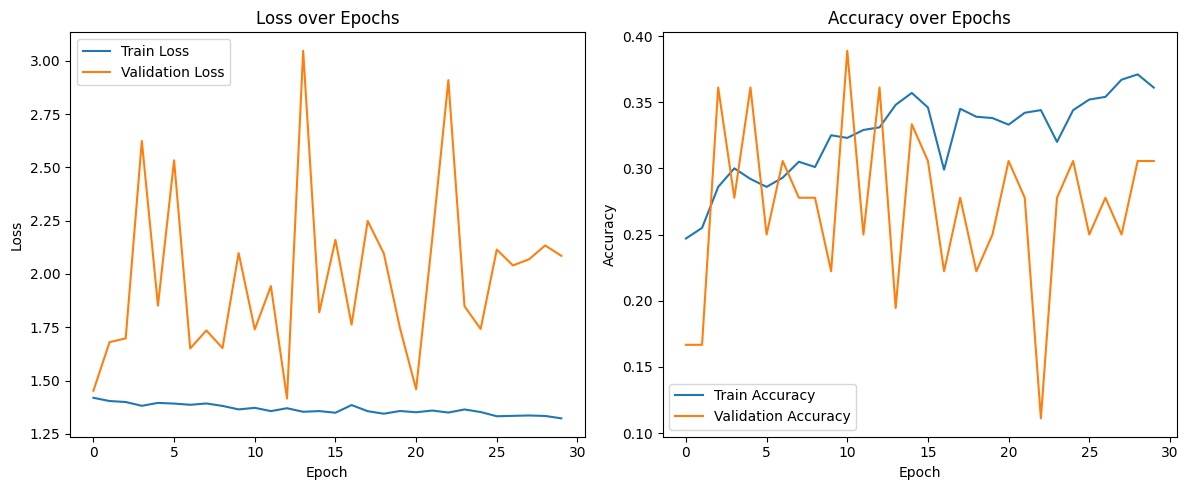

In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint

# Define the checkpoint callback to save the model every 5 epochs
checkpoint_callback = ModelCheckpoint(
    'model_epoch_{epoch:02d}.keras',  # Saves with the epoch number
    save_freq=10 * len(X_train) // 16,  # Save every 5 epochs (adjust batch size as necessary)
    save_best_only=False,  # Optionally save only the best model
    verbose=1
)

# Fit the model with the callback
with tf.device('/gpu:0'):
    history = model.fit(
        train_generator,
        validation_data=(X_valid, y_valid),
        epochs=30,
        batch_size=8,
        verbose=1,
        callbacks=[checkpoint_callback]
    )

# Plot loss and accuracy over epochs
plt.figure(figsize=(12, 5))

# Plot training & validation loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Show plots
plt.tight_layout()
plt.show()
